Subsection 1 & 2

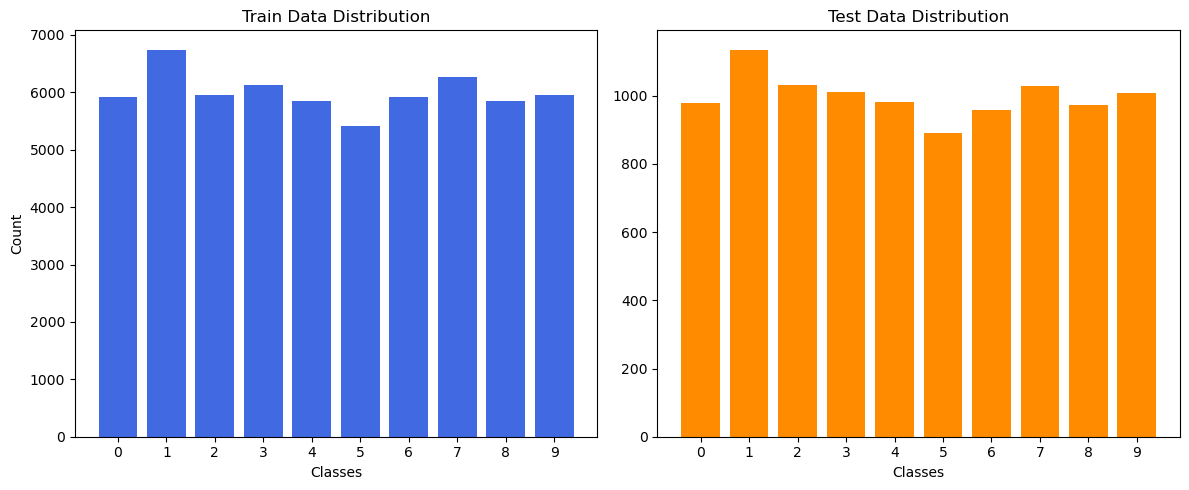

--- Training Autoencoder with Latent Dim = 8 ---
Epoch [1/15], Loss: 0.0511
Epoch [2/15], Loss: 0.0412
Epoch [3/15], Loss: 0.0379
Epoch [4/15], Loss: 0.0357
Epoch [5/15], Loss: 0.0349
Epoch [6/15], Loss: 0.0339
Epoch [7/15], Loss: 0.0335
Epoch [8/15], Loss: 0.0330
Epoch [9/15], Loss: 0.0328
Epoch [10/15], Loss: 0.0322
Epoch [11/15], Loss: 0.0318
Epoch [12/15], Loss: 0.0310
Epoch [13/15], Loss: 0.0308
Epoch [14/15], Loss: 0.0307
Epoch [15/15], Loss: 0.0306

--- Training Autoencoder with Latent Dim = 4 ---
Epoch [1/15], Loss: 0.0665
Epoch [2/15], Loss: 0.0551
Epoch [3/15], Loss: 0.0507
Epoch [4/15], Loss: 0.0487
Epoch [5/15], Loss: 0.0475
Epoch [6/15], Loss: 0.0466
Epoch [7/15], Loss: 0.0462
Epoch [8/15], Loss: 0.0459
Epoch [9/15], Loss: 0.0452
Epoch [10/15], Loss: 0.0446
Epoch [11/15], Loss: 0.0439
Epoch [12/15], Loss: 0.0436
Epoch [13/15], Loss: 0.0432
Epoch [14/15], Loss: 0.0430
Epoch [15/15], Loss: 0.0429


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from load_MNITS_data import read_images, read_labels

train_images = read_images("./Data/train-images.idx3-ubyte")
train_labels = read_labels("./Data/train-labels.idx1-ubyte")
test_images  = read_images("./Data/t10k-images.idx3-ubyte")
test_labels  = read_labels("./Data/t10k-labels.idx1-ubyte")

# ---------------------------------------------------------
# Subsection 1: Plot distribution and preprocessing
# ---------------------------------------------------------

# Plot data distribution
def plot_distribution(train_lbls, test_lbls):
    train_counts = np.bincount(train_lbls)
    test_counts = np.bincount(test_lbls)
    classes = np.arange(10)

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    ax[0].bar(classes, train_counts, color='royalblue')
    ax[0].set_title("Train Data Distribution")
    ax[0].set_xticks(classes)
    ax[0].set_xlabel("Classes")
    ax[0].set_ylabel("Count")

    ax[1].bar(classes, test_counts, color='darkorange')
    ax[1].set_title("Test Data Distribution")
    ax[1].set_xticks(classes)
    ax[1].set_xlabel("Classes")

    plt.tight_layout()
    plt.savefig("data_distribution.png", dpi=300)
    plt.show()

plot_distribution(train_labels, test_labels)

# Data preprocessing function
def preprocess(images):
    # Normalize pixel values to [0, 1]
    images_norm = images.astype(np.float32) / 255.0
    # Flatten dimensions to 784 (28*28)
    images_flat = images_norm.reshape(images_norm.shape[0], -1)
    return torch.tensor(images_flat)

X_train = preprocess(train_images)
X_test = preprocess(test_images)

train_dataset = TensorDataset(X_train, X_train)
test_dataset = TensorDataset(X_test, X_test)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ---------------------------------------------------------
# Subsection 2: Implement autoencoder architectures
# ---------------------------------------------------------

class Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super(Autoencoder, self).__init__()
        
        # Encoder part
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
            nn.ReLU()
        )
        
        # Decoder part
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.ReLU()
        )

    def forward(self, x):
        latent_representation = self.encoder(x)
        reconstructed = self.decoder(latent_representation)
        return reconstructed

model_latent_8 = Autoencoder(latent_dim=8)
model_latent_4 = Autoencoder(latent_dim=4)

# Training function
def train_model(model, dataloader, epochs=15, lr=1e-3):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    loss_history = []
    
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for data in dataloader:
            inputs, targets = data
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            
        avg_loss = total_loss / len(dataloader)
        loss_history.append(avg_loss)
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}')
        
    return loss_history

print("--- Training Autoencoder with Latent Dim = 8 ---")
history_8 = train_model(model_latent_8, train_loader, epochs=15)

print("\n--- Training Autoencoder with Latent Dim = 4 ---")
history_4 = train_model(model_latent_4, train_loader, epochs=15)

Subsection 3 & 4 & 5

>>> Training Autoencoder (Latent=8) ...
AE Epoch 1/20 | Train MSE: 0.0305 | Test MSE: 0.0304
AE Epoch 2/20 | Train MSE: 0.0303 | Test MSE: 0.0303
AE Epoch 3/20 | Train MSE: 0.0302 | Test MSE: 0.0303
AE Epoch 4/20 | Train MSE: 0.0301 | Test MSE: 0.0302
AE Epoch 5/20 | Train MSE: 0.0297 | Test MSE: 0.0298
AE Epoch 6/20 | Train MSE: 0.0295 | Test MSE: 0.0297
AE Epoch 7/20 | Train MSE: 0.0295 | Test MSE: 0.0297
AE Epoch 8/20 | Train MSE: 0.0294 | Test MSE: 0.0296
AE Epoch 9/20 | Train MSE: 0.0293 | Test MSE: 0.0296
AE Epoch 10/20 | Train MSE: 0.0293 | Test MSE: 0.0295
AE Epoch 11/20 | Train MSE: 0.0292 | Test MSE: 0.0294
AE Epoch 12/20 | Train MSE: 0.0292 | Test MSE: 0.0294
AE Epoch 13/20 | Train MSE: 0.0290 | Test MSE: 0.0290
AE Epoch 14/20 | Train MSE: 0.0287 | Test MSE: 0.0289
AE Epoch 15/20 | Train MSE: 0.0286 | Test MSE: 0.0289
AE Epoch 16/20 | Train MSE: 0.0286 | Test MSE: 0.0288
AE Epoch 17/20 | Train MSE: 0.0284 | Test MSE: 0.0286
AE Epoch 18/20 | Train MSE: 0.0284 | Test MSE: 0.02

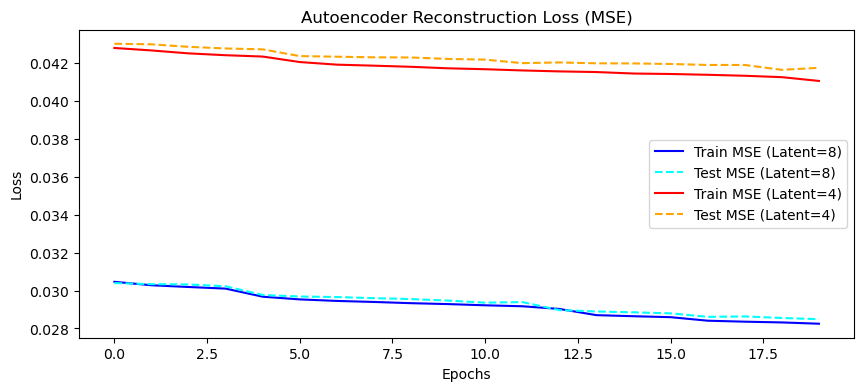


>>> Training Classifier (8-Neuron Encoder) ...
Clf Epoch 1/20 | Train Loss: 2.1030 | Test Loss: 1.7073 | Test Acc: 36.66%
Clf Epoch 2/20 | Train Loss: 1.4610 | Test Loss: 1.2857 | Test Acc: 54.23%
Clf Epoch 3/20 | Train Loss: 1.1699 | Test Loss: 1.0972 | Test Acc: 62.72%
Clf Epoch 4/20 | Train Loss: 1.0307 | Test Loss: 0.9918 | Test Acc: 68.08%
Clf Epoch 5/20 | Train Loss: 0.9473 | Test Loss: 0.9153 | Test Acc: 71.29%
Clf Epoch 6/20 | Train Loss: 0.8844 | Test Loss: 0.8609 | Test Acc: 72.40%
Clf Epoch 7/20 | Train Loss: 0.8436 | Test Loss: 0.8315 | Test Acc: 73.40%
Clf Epoch 8/20 | Train Loss: 0.8189 | Test Loss: 0.8110 | Test Acc: 74.54%
Clf Epoch 9/20 | Train Loss: 0.8023 | Test Loss: 0.7987 | Test Acc: 74.99%
Clf Epoch 10/20 | Train Loss: 0.7900 | Test Loss: 0.7873 | Test Acc: 75.13%
Clf Epoch 11/20 | Train Loss: 0.7805 | Test Loss: 0.7833 | Test Acc: 74.97%
Clf Epoch 12/20 | Train Loss: 0.7733 | Test Loss: 0.7747 | Test Acc: 75.04%
Clf Epoch 13/20 | Train Loss: 0.7675 | Test Loss:

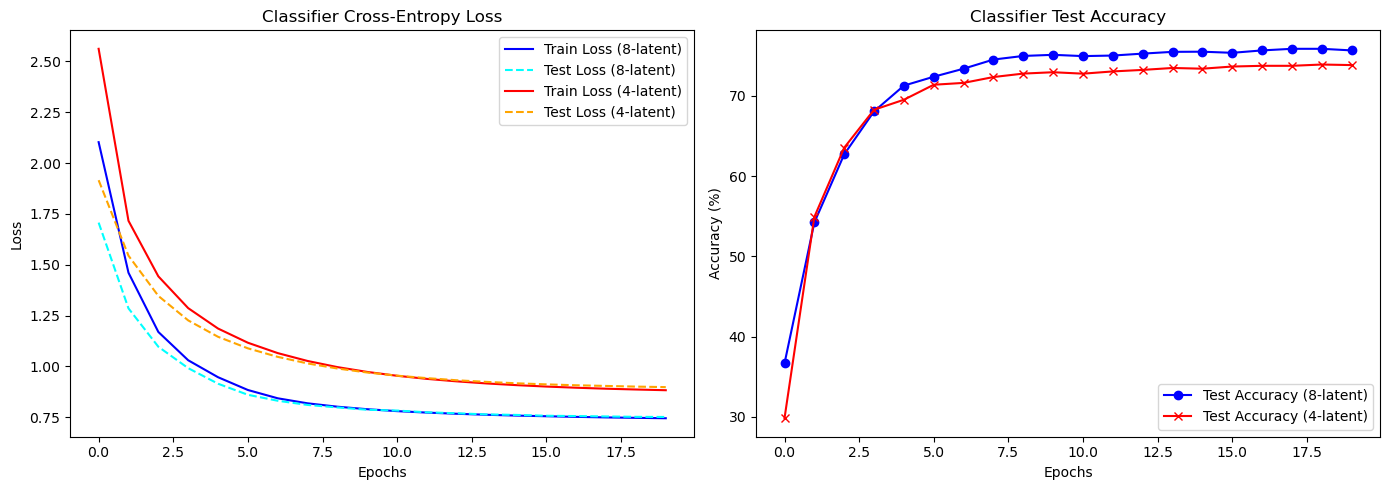


Trainable parameters in 8-latent Classifier: 86
Trainable parameters in 4-latent Classifier: 50


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt 

# ---------------------------------------------------------
# Subsection 3: Train autoencoder (20 epochs) and plot loss
# ---------------------------------------------------------

def train_autoencoder(model, train_loader, test_loader, epochs=20, lr=1e-3):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    train_losses, test_losses = [], []
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for inputs, _ in train_loader:
            inputs = inputs.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, inputs)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
        model.eval()
        test_loss = 0
        with torch.no_grad():
            for inputs, _ in test_loader:
                inputs = inputs.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, inputs)
                test_loss += loss.item()
                
        train_losses.append(train_loss / len(train_loader))
        test_losses.append(test_loss / len(test_loader))
        print(f'AE Epoch {epoch+1}/{epochs} | Train MSE: {train_losses[-1]:.4f} | Test MSE: {test_losses[-1]:.4f}')
        
    return train_losses, test_losses

print(">>> Training Autoencoder (Latent=8) ...")
train_loss_ae8, test_loss_ae8 = train_autoencoder(model_latent_8, train_loader, test_loader, epochs=20)

print("\n>>> Training Autoencoder (Latent=4) ...")
train_loss_ae4, test_loss_ae4 = train_autoencoder(model_latent_4, train_loader, test_loader, epochs=20)

# Plot autoencoder loss
plt.figure(figsize=(10, 4))
plt.plot(train_loss_ae8, label='Train MSE (Latent=8)', color='blue')
plt.plot(test_loss_ae8, label='Test MSE (Latent=8)', color='cyan', linestyle='--')
plt.plot(train_loss_ae4, label='Train MSE (Latent=4)', color='red')
plt.plot(test_loss_ae4, label='Test MSE (Latent=4)', color='orange', linestyle='--')
plt.title('Autoencoder Reconstruction Loss (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig("ae_loss.png", dpi=300)
plt.show()

# ---------------------------------------------------------
# Subsection 4 and 5: Build and train feedforward network (Classifier)
# ---------------------------------------------------------

y_train_tensor = torch.tensor(train_labels, dtype=torch.long)
y_test_tensor = torch.tensor(test_labels, dtype=torch.long)

train_cls_dataset = TensorDataset(X_train, y_train_tensor)
test_cls_dataset = TensorDataset(X_test, y_test_tensor)

train_cls_loader = DataLoader(train_cls_dataset, batch_size=128, shuffle=True)
test_cls_loader = DataLoader(test_cls_dataset, batch_size=128, shuffle=False)

# Define 8-neuron classifier architecture
class Classifier8(nn.Module):
    def __init__(self, pretrained_encoder):
        super(Classifier8, self).__init__()
        self.encoder = pretrained_encoder
        
        for param in self.encoder.parameters():
            param.requires_grad = False
            
        self.classifier = nn.Sequential(
            nn.Linear(8, 4),
            nn.ReLU(),
            nn.Linear(4, 10)
        )

    def forward(self, x):
        latent = self.encoder(x)
        out = self.classifier(latent)
        return out

# Define 4-neuron classifier architecture
class Classifier4(nn.Module):
    def __init__(self, pretrained_encoder):
        super(Classifier4, self).__init__()
        self.encoder = pretrained_encoder
        for param in self.encoder.parameters():
            param.requires_grad = False
            
        self.classifier = nn.Sequential(
            nn.Linear(4, 10)
        )

    def forward(self, x):
        latent = self.encoder(x)
        out = self.classifier(latent)
        return out

encoder_8 = model_latent_8.encoder
encoder_4 = model_latent_4.encoder

clf_model_8 = Classifier8(encoder_8)
clf_model_4 = Classifier4(encoder_4)

# Classifier training function
def train_classifier(model, train_loader, test_loader, epochs=20, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.classifier.parameters(), lr=lr)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    history = {'train_loss': [], 'test_loss': [], 'test_acc': []}
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
        model.eval()
        test_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                test_loss += loss.item()
                
                _, predicted = torch.max(outputs.data, 1)
                total += targets.size(0)
                correct += (predicted == targets).sum().item()
                
        history['train_loss'].append(train_loss / len(train_loader))
        history['test_loss'].append(test_loss / len(test_loader))
        history['test_acc'].append(100 * correct / total)
        
        print(f'Clf Epoch {epoch+1}/{epochs} | Train Loss: {history["train_loss"][-1]:.4f} | Test Loss: {history["test_loss"][-1]:.4f} | Test Acc: {history["test_acc"][-1]:.2f}%')
        
    return history

print("\n>>> Training Classifier (8-Neuron Encoder) ...")
hist_clf_8 = train_classifier(clf_model_8, train_cls_loader, test_cls_loader, epochs=20)

print("\n>>> Training Classifier (4-Neuron Encoder) ...")
hist_clf_4 = train_classifier(clf_model_4, train_cls_loader, test_cls_loader, epochs=20)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax[0].plot(hist_clf_8['train_loss'], label='Train Loss (8-latent)', color='blue')
ax[0].plot(hist_clf_8['test_loss'], label='Test Loss (8-latent)', color='cyan', linestyle='--')
ax[0].plot(hist_clf_4['train_loss'], label='Train Loss (4-latent)', color='red')
ax[0].plot(hist_clf_4['test_loss'], label='Test Loss (4-latent)', color='orange', linestyle='--')
ax[0].set_title('Classifier Cross-Entropy Loss')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()

# Accuracy plot
ax[1].plot(hist_clf_8['test_acc'], label='Test Accuracy (8-latent)', color='blue', marker='o')
ax[1].plot(hist_clf_4['test_acc'], label='Test Accuracy (4-latent)', color='red', marker='x')
ax[1].set_title('Classifier Test Accuracy')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
ax[1].legend()

plt.tight_layout()
plt.savefig("classifier_metrics.png", dpi=300)
plt.show()

# Count number of classifier parameters
def count_parameters(model):
    return sum(p.numel() for p in model.classifier.parameters() if p.requires_grad)

print(f"\nTrainable parameters in 8-latent Classifier: {count_parameters(clf_model_8)}")
print(f"Trainable parameters in 4-latent Classifier: {count_parameters(clf_model_4)}")